# Proyecto 1 — Monitoreo transaccional: detectar lo que el orden revela

**Universidad del Valle · Deep Learning 2026 · Kevin Recinos**

Integrantes: Gualim · Ocaña

**Pregunta central.** ¿El orden de las transacciones aporta información que las variables
agregadas no capturan, bajo qué condiciones y cuánto vale esa información en quetzales?

**Ruta de datos: A — generador sintético propio.** Se eligió sobre la Ruta B porque permite
controlar qué mecanismo de fraude depende del orden y cuál no. Ese control es lo que convierte la
comparación A vs B en evidencia: si el modelo secuencial gana solo donde el orden importa por
construcción, la conclusión es verificable y no una correlación afortunada.

Este notebook es autocontenido: no importa código propio. Todo lo que produce un número está a la
vista.

| Bloque | Contenido | Evidencia del informe |
|---|---|---|
| 0 | Configuración y entorno | Reproducibilidad |
| 1 | Generador, secuencias, partición temporal, antifuga | 1 — Integridad de datos |
| 2 | Modelo A (sin orden) y Modelo B (secuencial) | 2 — Comparación común |
| 3 | Permutación controlada y segunda prueba | 3 — Valor del orden |
| 4 | Apuesta C: hipótesis, control, veredicto | 4 — Apuesta del equipo |
| 5 | Umbral, costo y recomendación | 5 y 6 — Decisión y límites |

## Bloque 0 — Configuración y entorno

Una sola semilla gobierna generación de datos, partición, inicialización de pesos y barajado de
lotes. Las constantes de diseño se declaran aquí, **antes** de ver ningún dato, y no se vuelven a
tocar.

In [1]:
import copy, hashlib, os, platform, random, time, warnings
from collections import deque
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
import joblib
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score, precision_recall_curve

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (7, 4), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 9})

In [2]:
SEED = 2026

RAIZ = Path.cwd()
DIR_DATOS, DIR_ARTEFACTOS, DIR_FIGURAS = RAIZ / "datos", RAIZ / "artefactos", RAIZ / "figuras"
for _d in (DIR_DATOS, DIR_ARTEFACTOS, DIR_FIGURAS):
    _d.mkdir(exist_ok=True)

# --- generador ---
N_TARJETAS = 6_000
DIAS_SIMULACION = 120
FECHA_INICIO = "2025-01-01"
TASA_FRAUDE_OBJETIVO = 0.012
MEZCLA_FRAUDE = {"F1_escalada": 0.45, "F2_rafaga": 0.35, "F3_atipico": 0.20}

# --- secuencias ---
LARGO_SECUENCIA = 20
MIN_EVENTOS_PREVIOS = 3

# --- particion temporal ---
CORTE_TRAIN, CORTE_VAL = 0.60, 0.80
DIAS_EMBARGO = 2

# --- economia de la decision ---
COSTO_FN, COSTO_FP = 4_200, 180
CARTERA_TARJETAS = 1_400_000

print(f"semilla {SEED} | fraude objetivo {TASA_FRAUDE_OBJETIVO:.1%} | FN Q{COSTO_FN:,} / FP Q{COSTO_FP:,}")
print("metrica principal: AUC-PR. La exactitud NO se reporta como principal:")
print(f"  con {TASA_FRAUDE_OBJETIVO:.1%} de positivos, predecir 'todo legitimo' ya da "
      f"{1-TASA_FRAUDE_OBJETIVO:.1%} de exactitud y cero valor.")

semilla 2026 | fraude objetivo 1.2% | FN Q4,200 / FP Q180
metrica principal: AUC-PR. La exactitud NO se reporta como principal:
  con 1.2% de positivos, predecir 'todo legitimo' ya da 98.8% de exactitud y cero valor.


In [3]:
def fijar_semillas(seed=SEED):
    """Fija random, numpy y torch. Se llama antes de cada entrenamiento para que
    reentrenar no dependa de cuantas celdas se corrieron antes."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.use_deterministic_algorithms(True, warn_only=True)
    return seed


def hash_df(df):
    """Huella estable de un DataFrame, para verificar reproducibilidad."""
    h = hashlib.sha256()
    h.update(pd.util.hash_pandas_object(df, index=True).values.tobytes())
    h.update(",".join(map(str, df.columns)).encode())
    return h.hexdigest()[:16]


fijar_semillas()
DISPOSITIVO = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("dispositivo:", DISPOSITIVO, "| hilos torch:", torch.get_num_threads())

pd.DataFrame([("python", platform.python_version()), ("plataforma", platform.platform()),
              ("numpy", np.__version__), ("pandas", pd.__version__),
              ("torch", torch.__version__), ("sklearn", __import__("sklearn").__version__)],
             columns=["componente", "version"])

dispositivo: cpu | hilos torch: 6


,componente,version
0,python,3.11.9
1,plataforma,Windows-10-10.0.26200-SP0
2,numpy,2.4.6
3,pandas,2.3.3
4,torch,2.13.0+cpu
5,sklearn,1.9.0


## Bloque 1 — Datos, secuencias y protocolo temporal

> **Evidencia 1 del informe: integridad de datos.**
> Origen, tamaño, tasa de fraude, construcción de secuencias, partición temporal y controles
> contra fuga de información.

### 1.1 Generador sintético — mecanismos de fraude

Cada tarjeta tiene un perfil propio: frecuencia de uso, monto típico, hora habitual y una lista de
comercios frecuentes. Sobre ese tráfico normal se inyectan episodios.

| Mecanismo | Patrón en palabras sencillas | ¿Depende del orden? |
|---|---|---|
| **F1 — escalada** | Varias compras pequeñas de prueba, en montos crecientes, y enseguida el golpe grande. | **Sí.** Los mismos montos en otro orden son una compra legítima. |
| **F2 — ráfaga** | Muchos cargos en pocos minutos, en comercios distintos y desde el extranjero. | Parcialmente: pesa más la densidad temporal que la secuencia exacta. |
| **F3 — atípico aislado** | Un solo cargo muy por encima del monto habitual de esa tarjeta. | **No.** Es el control del experimento. |

**El control que hace honesta la comparación.** Junto a cada escalada se generan dos *sesiones
legítimas*: mismos montos, misma ventana, mismos comercios nuevos, mismo canal — pero en orden
**no creciente**. Sin ellas, "varias compras chicas y una grande" sería separable con solo mirar
el promedio y el máximo de la ventana, y el orden no tendría nada que aportar. Con ellas, la única
diferencia sistemática entre fraude y no fraude en F1 es la secuencia.

**Dónde esperamos que el modelo falle.** Las primeras sondas de una escalada están etiquetadas
como fraude —la tarjeta ya está comprometida— pero son indistinguibles de una compra pequeña
cualquiera: en ese punto todavía no existe historia que delate el patrón. Ningún modelo debería
detectarlas.

In [4]:
CATEGORIAS = ("supermercado", "restaurante", "combustible", "farmacia", "ropa",
              "electronica", "viajes", "servicios", "entretenimiento")
CANALES = ("pos", "ecommerce", "atm", "recurrente")

# Factor de escala del monto tipico por categoria.
ESCALA_CATEGORIA = np.array([1.4, 0.6, 0.9, 0.5, 1.1, 2.6, 3.2, 1.0, 0.7])

# P(canal | categoria); filas en el orden de CATEGORIAS.
P_CANAL = np.array([
    [0.88, 0.06, 0.03, 0.03],   # supermercado
    [0.90, 0.08, 0.01, 0.01],   # restaurante
    [0.95, 0.01, 0.03, 0.01],   # combustible
    [0.90, 0.07, 0.01, 0.02],   # farmacia
    [0.55, 0.43, 0.01, 0.01],   # ropa
    [0.40, 0.58, 0.01, 0.01],   # electronica
    [0.15, 0.83, 0.01, 0.01],   # viajes
    [0.10, 0.25, 0.02, 0.63],   # servicios
    [0.30, 0.60, 0.02, 0.08],   # entretenimiento
])

N_COMERCIOS = 1_200
COMERCIOS_HABITUALES = 8
P_COMERCIO_HABITUAL = 0.85
MINUTOS_POR_DIA = 1_440

# Tamano medio de episodio: traduce la tasa de fraude objetivo a un numero de episodios.
TAM_ESCALADA, TAM_RAFAGA = 5.0, 10.5
DISTRACTORES_POR_ESCALADA = 2.0

COLUMNAS_TX = ["id_transaccion", "id_tarjeta", "timestamp", "monto", "id_comercio",
               "categoria", "canal", "extranjero", "es_fraude", "mecanismo", "id_episodio"]


@dataclass
class Poblacion:
    tasa: np.ndarray          # transacciones por dia
    mu: np.ndarray            # log-monto tipico
    sigma: np.ndarray         # dispersion del log-monto
    hora_pico: np.ndarray
    habituales: np.ndarray    # (n_tarjetas, COMERCIOS_HABITUALES)
    cat_comercio: np.ndarray  # (N_COMERCIOS,)

    @property
    def n(self):
        return self.tasa.size

In [5]:
def muestrear_fila(rng, probs):
    """Muestreo categorico con una distribucion distinta por fila."""
    acum = np.cumsum(probs, axis=1)
    u = rng.random((probs.shape[0], 1))
    return np.minimum((u > acum).sum(axis=1), probs.shape[1] - 1)


def construir_poblacion(rng, n_tarjetas):
    cat_comercio = rng.integers(0, len(CATEGORIAS), N_COMERCIOS)
    prefs = rng.dirichlet(np.full(len(CATEGORIAS), 0.8), n_tarjetas)

    # Los comercios habituales se sortean por categoria preferida: el gusto de cada
    # tarjeta queda implicito en su lista de comercios.
    cat_slots = muestrear_fila(rng, np.repeat(prefs, COMERCIOS_HABITUALES, axis=0))
    habituales = np.empty(cat_slots.size, dtype=np.int64)
    for c in range(len(CATEGORIAS)):
        candidatos = np.flatnonzero(cat_comercio == c)
        sel = cat_slots == c
        habituales[sel] = rng.choice(candidatos, sel.sum())

    return Poblacion(
        tasa=rng.gamma(2.0, 0.225, n_tarjetas),
        mu=rng.normal(4.2, 0.45, n_tarjetas),
        sigma=rng.uniform(0.45, 0.80, n_tarjetas),
        hora_pico=rng.normal(13.5, 2.0, n_tarjetas),
        habituales=habituales.reshape(n_tarjetas, COMERCIOS_HABITUALES),
        cat_comercio=cat_comercio,
    )


def canal_y_pais(rng, categorias):
    canal = muestrear_fila(rng, P_CANAL[categorias])
    p_ext = np.where(canal == 1, 0.09, 0.012)
    return canal, (rng.random(canal.size) < p_ext).astype(np.int8)


def base_legitima(rng, pob, dias):
    """Trafico normal: llegadas por tarjeta, hora preferida y comercios habituales."""
    n_tx = rng.poisson(pob.tasa * dias)
    tarjeta = np.repeat(np.arange(pob.n), n_tx)
    n = tarjeta.size

    dia = rng.integers(0, dias, n)
    hora = np.clip(rng.normal(pob.hora_pico[tarjeta], 3.5), 0.0, 23.99)
    minuto = dia * MINUTOS_POR_DIA + hora * 60.0

    habitual = rng.random(n) < P_COMERCIO_HABITUAL
    col = rng.integers(0, COMERCIOS_HABITUALES, n)
    comercio = np.where(habitual, pob.habituales[tarjeta, col], rng.integers(0, N_COMERCIOS, n))

    categoria = pob.cat_comercio[comercio]
    canal, extranjero = canal_y_pais(rng, categoria)
    monto = np.exp(rng.normal(pob.mu[tarjeta], pob.sigma[tarjeta])) * ESCALA_CATEGORIA[categoria]

    return dict(id_tarjeta=tarjeta, minuto=minuto, monto=monto, id_comercio=comercio,
                categoria=categoria, canal=canal, extranjero=extranjero,
                es_fraude=np.zeros(n, np.int8),
                mecanismo=np.full(n, "legitimo", dtype=object),
                id_episodio=np.full(n, -1, np.int64))

In [6]:
def fila_episodio(pob, tarjeta, minutos, montos, comercios, canal, extranjero,
                  es_fraude, mecanismo, id_episodio):
    k = montos.size
    return dict(
        id_tarjeta=np.full(k, tarjeta, np.int64), minuto=minutos, monto=montos,
        id_comercio=comercios, categoria=pob.cat_comercio[comercios],
        canal=np.full(k, canal, np.int64), extranjero=np.full(k, extranjero, np.int8),
        es_fraude=np.full(k, es_fraude, np.int8),
        mecanismo=np.full(k, mecanismo, dtype=object),
        id_episodio=np.full(k, id_episodio, np.int64))


def montos_sesion(rng, tipico, k):
    """Sondas pequenas mas un golpe grande, sin ordenar."""
    return np.append(rng.uniform(5.0, 45.0, k), tipico * rng.uniform(8.0, 25.0))


def escaladas(rng, pob, n_episodios, dias, id0):
    """F1: fraude dependiente del orden, montos crecientes que rematan en el golpe."""
    eps = []
    for i in range(n_episodios):
        t = int(rng.integers(0, pob.n))
        montos = np.sort(montos_sesion(rng, float(np.exp(pob.mu[t])), int(rng.integers(3, 6))))
        inicio = rng.uniform(0, dias) * MINUTOS_POR_DIA
        minutos = inicio + np.cumsum(rng.uniform(1.0, 8.0, montos.size))
        comercios = rng.choice(N_COMERCIOS, montos.size, replace=False)
        eps.append(fila_episodio(pob, t, minutos, montos, comercios, 1, 1, 1,
                                 "F1_escalada", id0 + i))
    return eps


def sesiones_legitimas(rng, pob, n_episodios, dias, id0):
    """Control de F1: mismos montos, ventana y comercios, en orden no creciente."""
    eps = []
    for i in range(n_episodios):
        t = int(rng.integers(0, pob.n))
        montos = montos_sesion(rng, float(np.exp(pob.mu[t])), int(rng.integers(3, 6)))
        while True:
            rng.shuffle(montos)
            if not np.all(np.diff(montos) > 0):
                break
        inicio = rng.uniform(0, dias) * MINUTOS_POR_DIA
        minutos = inicio + np.cumsum(rng.uniform(1.0, 8.0, montos.size))
        comercios = rng.choice(N_COMERCIOS, montos.size, replace=False)
        eps.append(fila_episodio(pob, t, minutos, montos, comercios, 1, 1, 0,
                                 "sesion_legitima", id0 + i))
    return eps


def rafagas(rng, pob, n_episodios, dias, id0):
    """F2: muchos cargos en pocos minutos, en comercios distintos."""
    eps = []
    for i in range(n_episodios):
        t = int(rng.integers(0, pob.n))
        k = int(rng.integers(7, 15))
        inicio = rng.uniform(0, dias) * MINUTOS_POR_DIA
        minutos = inicio + np.sort(rng.uniform(0, rng.uniform(3.0, 20.0), k))
        montos = float(np.exp(pob.mu[t])) * rng.uniform(0.5, 2.0, k)
        comercios = rng.choice(N_COMERCIOS, k, replace=False)
        eps.append(fila_episodio(pob, t, minutos, montos, comercios, 0, 1, 1,
                                 "F2_rafaga", id0 + i))
    return eps


def atipicos(rng, pob, n_episodios, dias, id0):
    """F3: cargo unico y aislado, muy por encima del monto habitual de la tarjeta."""
    t = rng.integers(0, pob.n, n_episodios)
    minutos = (rng.integers(0, dias, n_episodios) * MINUTOS_POR_DIA
               + rng.uniform(0, MINUTOS_POR_DIA, n_episodios))
    montos = np.exp(pob.mu[t]) * rng.uniform(15.0, 40.0, n_episodios)
    comercios = rng.integers(0, N_COMERCIOS, n_episodios)
    categoria = pob.cat_comercio[comercios]
    canal, _ = canal_y_pais(rng, categoria)
    return dict(id_tarjeta=t, minuto=minutos, monto=montos, id_comercio=comercios,
                categoria=categoria, canal=canal,
                extranjero=(rng.random(n_episodios) < 0.35).astype(np.int8),
                es_fraude=np.ones(n_episodios, np.int8),
                mecanismo=np.full(n_episodios, "F3_atipico", dtype=object),
                id_episodio=id0 + np.arange(n_episodios))

In [7]:
def contar_episodios(n_base, tasa):
    """Reparte la tasa objetivo entre mecanismos. Los distractores suman filas
    legitimas, asi que entran en el denominador."""
    extra = 1.0 + DISTRACTORES_POR_ESCALADA * MEZCLA_FRAUDE["F1_escalada"]
    total = tasa * n_base / (1.0 - tasa * extra)
    n_f1 = round(MEZCLA_FRAUDE["F1_escalada"] * total / TAM_ESCALADA)
    return {"F1_escalada": n_f1,
            "F2_rafaga": round(MEZCLA_FRAUDE["F2_rafaga"] * total / TAM_RAFAGA),
            "F3_atipico": round(MEZCLA_FRAUDE["F3_atipico"] * total),
            "sesion_legitima": round(DISTRACTORES_POR_ESCALADA * n_f1)}


def generar(seed=SEED, n_tarjetas=N_TARJETAS, dias=DIAS_SIMULACION):
    """Historial completo de transacciones, ordenado por tarjeta y tiempo."""
    rng = np.random.default_rng(seed)
    pob = construir_poblacion(rng, n_tarjetas)
    base = base_legitima(rng, pob, dias)

    n = contar_episodios(base["monto"].size, TASA_FRAUDE_OBJETIVO)
    partes, id0 = [base], 0
    for constructor, clave in ((escaladas, "F1_escalada"), (rafagas, "F2_rafaga"),
                               (sesiones_legitimas, "sesion_legitima")):
        partes.extend(constructor(rng, pob, n[clave], dias, id0))
        id0 += n[clave]
    partes.append(atipicos(rng, pob, n["F3_atipico"], dias, id0))

    df = pd.DataFrame({k: np.concatenate([p[k] for p in partes]) for k in base})
    df["timestamp"] = pd.Timestamp(FECHA_INICIO) + pd.to_timedelta(df.pop("minuto").round(), unit="m")
    df["monto"] = df["monto"].round(2)
    df["categoria"] = pd.Categorical.from_codes(df["categoria"], CATEGORIAS)
    df["canal"] = pd.Categorical.from_codes(df["canal"], CANALES)
    df["mecanismo"] = df["mecanismo"].astype("category")
    df = df.sort_values(["id_tarjeta", "timestamp"], kind="mergesort").reset_index(drop=True)
    df.insert(0, "id_transaccion", np.arange(len(df), dtype=np.int64))
    return df[COLUMNAS_TX]


tx = generar()
huella = hash_df(tx)

print(f"transacciones : {len(tx):,}")
print(f"tarjetas      : {tx.id_tarjeta.nunique():,}")
print(f"ventana       : {tx.timestamp.min():%Y-%m-%d} a {tx.timestamp.max():%Y-%m-%d}")
print(f"tasa de fraude: {tx.es_fraude.mean()*100:.3f} %  (objetivo {TASA_FRAUDE_OBJETIVO*100:.3f} %)")
print(f"huella        : {huella}")

assert huella == hash_df(generar()), "el generador no es reproducible con la misma semilla"
assert huella != hash_df(generar(seed=SEED + 1)), "cambiar la semilla no cambio los datos"
print("reproducibilidad verificada: misma semilla -> misma huella, otra semilla -> otra huella")

transacciones : 324,603
tarjetas      : 5,991
ventana       : 2025-01-01 a 2025-04-30
tasa de fraude: 1.197 %  (objetivo 1.200 %)
huella        : 2a9dc26504bd733d


reproducibilidad verificada: misma semilla -> misma huella, otra semilla -> otra huella


**Composición del conjunto.** Las sesiones legítimas no son fraude: son el control de F1.

In [8]:
_ep = tx.id_episodio.where(tx.id_episodio >= 0)
composicion = (tx.assign(episodio=_ep).groupby("mecanismo", observed=True)
               .agg(transacciones=("es_fraude", "size"), episodios=("episodio", "nunique"),
                    etiqueta=("es_fraude", "max"), monto_mediano=("monto", "median"))
               .sort_values("transacciones", ascending=False))
composicion["% del total"] = (composicion.transacciones / len(tx) * 100).round(3)
composicion

,transacciones,episodios,etiqueta,monto_mediano,% del total
mecanismo,,,,,
legitimo,317186,0,0,71.23,97.715
sesion_legitima,3531,702,0,30.60,1.088
F1_escalada,1766,351,1,29.49,0.544
F2_rafaga,1341,130,1,79.63,0.413
F3_atipico,779,779,1,1706.78,0.240


**Una escalada y su control, lado a lado.** Mismos ingredientes, distinto orden.

In [9]:
def episodio_ejemplo(mecanismo, golpe_al_final):
    """Primer episodio del mecanismo cuyo monto mayor cae (o no) en la ultima posicion."""
    cols = ["timestamp", "monto", "id_comercio", "canal", "es_fraude"]
    for eid in tx.loc[tx.mecanismo == mecanismo, "id_episodio"].unique():
        ep = tx.loc[tx.id_episodio == eid, cols]
        if (ep.monto.values.argmax() == len(ep) - 1) == golpe_al_final:
            return ep.reset_index(drop=True)

print("F1_escalada (fraude): montos crecientes que rematan en el golpe")
print(episodio_ejemplo("F1_escalada", True).to_string(index=False))
print()
print("sesion_legitima (control): mismos ingredientes, el golpe no va al final")
print(episodio_ejemplo("sesion_legitima", False).to_string(index=False))

F1_escalada (fraude): montos crecientes que rematan en el golpe
          timestamp  monto  id_comercio     canal  es_fraude
2025-03-28 20:54:00  13.62          114 ecommerce          1
2025-03-28 20:57:00  38.65           95 ecommerce          1
2025-03-28 21:03:00  40.71         1109 ecommerce          1
2025-03-28 21:04:00  41.13          100 ecommerce          1
2025-03-28 21:08:00 539.13          304 ecommerce          1

sesion_legitima (control): mismos ingredientes, el golpe no va al final
          timestamp  monto  id_comercio     canal  es_fraude
2025-03-10 12:01:00  42.51          287 ecommerce          0
2025-03-10 12:03:00 768.77          753 ecommerce          0
2025-03-10 12:07:00   7.70          792 ecommerce          0
2025-03-10 12:14:00  15.68          463 ecommerce          0
2025-03-10 12:19:00  28.14          938 ecommerce          0
2025-03-10 12:23:00  29.53          623 ecommerce          0


**El control funciona.** Los agregados de ventana —conteo, suma, promedio, máximo, diversidad de
comercios, duración— son estadísticamente iguales entre F1 y su control. Lo único que separa a los
dos grupos es la monotonía de la secuencia.

In [10]:
comparables = tx[tx.mecanismo.isin(["F1_escalada", "sesion_legitima"])]
por_episodio = comparables.groupby(["mecanismo", "id_episodio"], observed=True).agg(
    eventos=("monto", "size"), suma=("monto", "sum"), promedio=("monto", "mean"),
    maximo=("monto", "max"), comercios=("id_comercio", "nunique"),
    duracion_min=("timestamp", lambda s: (s.max() - s.min()).total_seconds() / 60))
agregados_episodio = por_episodio.groupby("mecanismo", observed=True).mean().round(2)

agregados_episodio["% creciente"] = (comparables.groupby(["mecanismo", "id_episodio"], observed=True)
    .monto.apply(lambda s: bool(np.all(np.diff(s.values) > 0)))
    .groupby("mecanismo", observed=True).mean() * 100).round(1)
agregados_episodio["% golpe al final"] = (comparables.groupby(["mecanismo", "id_episodio"], observed=True)
    .monto.apply(lambda s: bool(s.values.argmax() == len(s) - 1))
    .groupby("mecanismo", observed=True).mean() * 100).round(1)
agregados_episodio

,eventos,suma,promedio,maximo,comercios,duracion_min,% creciente,% golpe al final
mecanismo,,,,,,,,
F1_escalada,5.03,1302.55,265.03,1203.14,5.03,18.23,99.7,100.0
sesion_legitima,5.03,1327.35,270.40,1225.12,5.03,18.08,0.0,20.4


La única señal que queda al alcance de un modelo sin orden es *dónde cae el monto grande*: en una
escalada siempre es el último evento, mientras que en el control cae al final solo una de cada
cinco veces. Ese solapamiento del 20 % es el techo que la línea base no puede superar en F1, y es
exactamente lo que el modelo secuencial debería poder romper.

In [11]:
ruta_datos = DIR_DATOS / "transacciones.csv"
tx.to_csv(ruta_datos, index=False)
print(f"{ruta_datos.name}: {ruta_datos.stat().st_size / 1e6:.1f} MB (derivado; se regenera con la semilla)")

transacciones.csv: 24.7 MB (derivado; se regenera con la semilla)


### 1.2 Construcción de secuencias

**Qué es un ejemplo.** La historia de una tarjeta hasta el evento actual **inclusive**, recortada
a los últimos 20 eventos y alineada a la derecha (el padding va a la izquierda).

**Qué se predice.** Si *ese* evento es fraudulento. Es el horizonte que enfrenta un motor
antifraude real: autorizar o bloquear la transacción que está ocurriendo ahora. A y B comparten
esta definición exacta, así que la comparación es sobre el mismo problema.

**Regla de arranque en frío.** Una tarjeta con menos de 3 transacciones previas no se puntúa: no
hay historia que leer. En producción esas tarjetas irían a un camino de reglas. La regla tiene un
costo que conviene declarar, no esconder, y se mide más abajo.

**Canales por evento.** `log_monto`, `log_dt` (minutos desde la transacción anterior de la misma
tarjeta), `hora_sin`/`hora_cos`, `extranjero`, `comercio_nuevo`, más `canal` y `categoría` como
índices para embeddings. Los ocho son **causales por construcción**: se calculan con la fila actual
y las anteriores de la misma tarjeta, sin ninguna estadística del conjunto. Por eso pueden
calcularse antes de partir los datos sin introducir fuga. La estandarización, que sí requiere
estadísticas globales, se deja para 1.4.

In [12]:
CANALES_NUM = ["log_monto", "log_dt", "hora_sin", "hora_cos", "extranjero", "comercio_nuevo"]
CANALES_CAT = ["canal", "categoria"]
DT_MAX_MIN = 60 * 24 * 30          # tope del hueco; tambien el valor de la primera transaccion
PARTICIONES = ("train", "val", "test")


@dataclass
class Datos:
    """`idx` y `mascara` indexan las tablas por transaccion (`num`, `cat`): la fila j de
    la secuencia i es la transaccion idx[i, j], valida solo si mascara[i, j]. Se guarda
    el indice y no el tensor expandido para no materializar (n, L, C)."""
    idx: np.ndarray          # (n, L) int32
    mascara: np.ndarray      # (n, L) bool
    num: np.ndarray          # (n_tx, 6) float32
    cat: np.ndarray          # (n_tx, 2) int16
    y: np.ndarray
    t: np.ndarray            # timestamp del evento objetivo
    particion: np.ndarray
    mecanismo: np.ndarray
    id_episodio: np.ndarray
    fila_tx: np.ndarray      # fila de la transaccion objetivo
    longitud: np.ndarray

    @property
    def n(self):
        return self.y.size

    def sel(self, particion):
        return np.flatnonzero(self.particion == particion)


def tabla_eventos(tx):
    dt = (tx.groupby("id_tarjeta", observed=True).timestamp.diff()
          .dt.total_seconds().div(60).fillna(DT_MAX_MIN).clip(upper=DT_MAX_MIN))
    hora = tx.timestamp.dt.hour + tx.timestamp.dt.minute / 60.0
    num = np.column_stack([
        np.log1p(tx.monto.to_numpy()),
        np.log1p(dt.to_numpy()),
        np.sin(2 * np.pi * hora.to_numpy() / 24.0),
        np.cos(2 * np.pi * hora.to_numpy() / 24.0),
        tx.extranjero.to_numpy(),
        (~tx.duplicated(["id_tarjeta", "id_comercio"])).to_numpy(),
    ]).astype(np.float32)
    cat = np.column_stack([tx.canal.cat.codes.to_numpy(),
                           tx.categoria.cat.codes.to_numpy()]).astype(np.int16)
    return num, cat


def cortes_temporales(tx):
    t0, t1 = tx.timestamp.min(), tx.timestamp.max()
    return t0 + (t1 - t0) * CORTE_TRAIN, t0 + (t1 - t0) * CORTE_VAL


def asignar_particion(t, corte_train, corte_val):
    """Las franjas de embargo quedan fuera para que ningun episodio se parta."""
    embargo = pd.Timedelta(days=DIAS_EMBARGO)
    p = np.full(len(t), "descarte", dtype=object)
    p[t < corte_train] = "train"
    p[(t >= corte_train + embargo) & (t < corte_val)] = "val"
    p[t >= corte_val + embargo] = "test"
    return p.astype("<U8")


def construir_secuencias(tx, largo=LARGO_SECUENCIA, min_previos=MIN_EVENTOS_PREVIOS):
    num, cat = tabla_eventos(tx)
    pos = tx.groupby("id_tarjeta", observed=True).cumcount().to_numpy()

    objetivo = np.flatnonzero(pos >= min_previos)      # arranque en frio
    desplazamiento = np.arange(largo - 1, -1, -1)
    idx = objetivo[:, None] - desplazamiento[None, :]
    mascara = (pos[objetivo][:, None] - desplazamiento[None, :]) >= 0
    idx = np.where(mascara, idx, 0).astype(np.int32)

    corte_train, corte_val = cortes_temporales(tx)
    t_obj = tx.timestamp.to_numpy()[objetivo]
    return Datos(idx=idx, mascara=mascara, num=num, cat=cat,
                 y=tx.es_fraude.to_numpy()[objetivo].astype(np.int8), t=t_obj,
                 particion=asignar_particion(pd.Series(t_obj), corte_train, corte_val),
                 mecanismo=tx.mecanismo.to_numpy()[objetivo],
                 id_episodio=tx.id_episodio.to_numpy()[objetivo],
                 fila_tx=objetivo.astype(np.int64),
                 longitud=np.minimum(pos[objetivo] + 1, largo).astype(np.int16))


datos = construir_secuencias(tx)
idx = {p: datos.sel(p) for p in PARTICIONES}

print(f"secuencias   : {datos.n:,} de {len(tx):,} transacciones")
print(f"descartadas  : {len(tx) - datos.n:,} por arranque en frio")
print(f"largo maximo : {LARGO_SECUENCIA} | minimo previos: {MIN_EVENTOS_PREVIOS}")
print(f"largo real   : mediana {np.median(datos.longitud):.0f}, media {datos.longitud.mean():.1f}")

secuencias   : 306,670 de 324,603 transacciones
descartadas  : 17,933 por arranque en frio
largo maximo : 20 | minimo previos: 3
largo real   : mediana 20, media 17.5


In [13]:
pos_tx = tx.groupby("id_tarjeta", observed=True).cumcount().to_numpy()
perdidas = tx[pos_tx < MIN_EVENTOS_PREVIOS]
print(f"costo del arranque en frio: {len(perdidas):,} transacciones fuera, "
      f"{int(perdidas.es_fraude.sum())} de ellas fraude")
print(perdidas[perdidas.es_fraude == 1].mecanismo.value_counts().to_string())

costo del arranque en frio: 17,933 transacciones fuera, 180 de ellas fraude
mecanismo
F3_atipico         90
F1_escalada        58
F2_rafaga          32
legitimo            0
sesion_legitima     0


**Lo que ve el modelo en un caso de escalada.** La secuencia siguiente termina en la *primera
sonda* del episodio: ya está etiquetada como fraude, pero todavía no hay nada en la historia que lo
delate. Es el caso donde esperamos —y queremos— que el modelo falle.

In [14]:
def mostrar_secuencia(fila, ultimos=8):
    eventos = datos.idx[fila][datos.mascara[fila]]
    cols = ["timestamp", "monto", "canal", "es_fraude", "mecanismo"]
    print(tx.loc[eventos, cols].tail(ultimos).to_string(index=False))
    print(f"-> objetivo: y={datos.y[fila]} | largo={datos.longitud[fila]} "
          f"| particion={datos.particion[fila]}")

montos_objetivo = tx.monto.to_numpy()[datos.fila_tx]
_esc = np.flatnonzero((datos.mecanismo == "F1_escalada") & (datos.particion == "train"))

# Las sondas van en orden creciente, asi que la de monto menor es la primera del episodio.
mostrar_secuencia(_esc[np.argmin(montos_objetivo[_esc])])

          timestamp  monto      canal  es_fraude   mecanismo
2025-01-02 15:00:00  47.23        pos          0    legitimo
2025-01-04 09:33:00  52.46  ecommerce          0    legitimo
2025-01-07 11:12:00   9.16 recurrente          0    legitimo
2025-01-13 16:20:00  20.88  ecommerce          0    legitimo
2025-02-04 07:50:00   5.15  ecommerce          1 F1_escalada
-> objetivo: y=1 | largo=5 | particion=train


### 1.3 Partición temporal y controles antifuga

Los cortes se hacen **por tiempo**, sobre el timestamp del evento objetivo: el 60 % más antiguo
entrena, el 20 % siguiente valida, el 20 % final prueba. Entre particiones hay una franja de
**embargo de 2 días** cuyos eventos no se usan como objetivo, para que ningún episodio de fraude
quede partido entre dos particiones y el modelo no vea en entrenamiento la mitad de un caso que
después se le evalúa.

**Un punto que puede confundirse con fuga y no lo es.** La secuencia de un ejemplo de validación
puede incluir eventos ocurridos durante el período de entrenamiento. Eso es exactamente lo que pasa
en producción: al puntuar una transacción, el historial de la tarjeta ya existe. La fuga sería usar
información *posterior* al evento objetivo, y eso es lo que verifican los controles de abajo.

**El conjunto de prueba se mira una sola vez**, después de fijar arquitectura, hiperparámetros y
umbral.

In [15]:
def resumen_particiones(d):
    df = pd.DataFrame({"particion": d.particion, "y": d.y, "t": d.t, "largo": d.longitud})
    orden = [*PARTICIONES, "descarte"]
    tabla = (df.groupby("particion", observed=True)
             .agg(secuencias=("y", "size"), fraudes=("y", "sum"), desde=("t", "min"),
                  hasta=("t", "max"), largo_medio=("largo", "mean"))
             .reindex([p for p in orden if p in set(df.particion)]))
    tabla["tasa_fraude_%"] = (tabla.fraudes / tabla.secuencias * 100).round(3)
    tabla["largo_medio"] = tabla.largo_medio.round(1)
    return tabla

corte_train, corte_val = cortes_temporales(tx)
print(f"corte train/val : {corte_train:%Y-%m-%d %H:%M}")
print(f"corte val/test  : {corte_val:%Y-%m-%d %H:%M}")
print(f"embargo         : {DIAS_EMBARGO} dias")
resumen_particiones(datos)

corte train/val : 2025-03-13 23:59
corte val/test  : 2025-04-06 23:59
embargo         : 2 dias


,secuencias,fraudes,desde,hasta,largo_medio,tasa_fraude_%
particion,,,,,,
train,177033,2291,2025-01-01 04:31:00,2025-03-13 23:59:00,15.9,1.294
val,59495,660,2025-03-16 00:00:00,2025-04-06 23:59:00,19.5,1.109
test,59410,644,2025-04-09 00:00:00,2025-04-30 23:59:00,19.7,1.084
descarte,10732,111,2025-03-14 00:00:00,2025-04-08 23:59:00,19.5,1.034


La tasa de fraude baja un poco de una partición a otra (1.29 → 1.11 → 1.08 %). Parte viene de la
regla de arranque en frío, que retira transacciones casi siempre legítimas concentradas al inicio
de cada tarjeta, y parte es variación del propio generador. No afecta la comparación A contra B,
que se hace **dentro** de la misma partición, pero sí implica que un AUC-PR de validación y uno de
prueba no son directamente comparables entre sí.

**Controles antifuga.** Cada uno lanza excepción si falla; no son mensajes decorativos.

In [16]:
def verificar_antifuga(d, tx):
    hechos = []
    t = pd.Series(d.t)
    limites = {p: (t[d.particion == p].min(), t[d.particion == p].max()) for p in PARTICIONES}
    assert limites["train"][1] < limites["val"][0], "train se solapa con val"
    assert limites["val"][1] < limites["test"][0], "val se solapa con test"
    hechos.append("el orden temporal train < val < test se cumple sin solape")

    embargo = pd.Timedelta(days=DIAS_EMBARGO)
    assert limites["val"][0] - limites["train"][1] >= embargo
    assert limites["test"][0] - limites["val"][1] >= embargo
    hechos.append(f"hay al menos {DIAS_EMBARGO} dias de embargo entre particiones")

    reales = d.particion != "descarte"
    ep = pd.DataFrame({"ep": d.id_episodio[reales], "p": d.particion[reales]})
    ep = ep[ep.ep >= 0]
    assert ep.groupby("ep").p.nunique().max() == 1, "un episodio quedo partido entre particiones"
    hechos.append("ningun episodio de fraude aparece en mas de una particion")

    # El padding va a la izquierda: se rellena con el evento real mas antiguo de cada
    # fila para que no rompa la comprobacion de monotonia.
    ts = tx.timestamp.to_numpy()[d.idx]
    tope = np.datetime64("2262-01-01")
    ts = np.where(d.mascara, ts, np.where(d.mascara, ts, tope).min(axis=1, keepdims=True))
    assert (np.diff(ts, axis=1) >= np.timedelta64(0)).all(), "una secuencia no esta ordenada"
    assert (ts <= d.t[:, None]).all(), "una secuencia contiene eventos posteriores al objetivo"
    hechos.append("ninguna secuencia contiene eventos posteriores a su evento objetivo")

    tarjeta = tx.id_tarjeta.to_numpy()[d.idx]
    misma = np.where(d.mascara, tarjeta, tarjeta[:, -1:])
    assert (misma == misma[:, -1:]).all(), "una secuencia mezcla tarjetas"
    hechos.append("cada secuencia contiene transacciones de una sola tarjeta")

    for p in PARTICIONES:
        assert d.y[d.particion == p].sum() > 0, f"la particion {p} no tiene fraude"
    hechos.append("las tres particiones contienen casos de fraude")
    return hechos


for control in verificar_antifuga(datos, tx):
    print(" [ok]", control)

 [ok] el orden temporal train < val < test se cumple sin solape
 [ok] hay al menos 2 dias de embargo entre particiones
 [ok] ningun episodio de fraude aparece en mas de una particion
 [ok] ninguna secuencia contiene eventos posteriores a su evento objetivo
 [ok] cada secuencia contiene transacciones de una sola tarjeta
 [ok] las tres particiones contienen casos de fraude


In [17]:
reparto = pd.crosstab(pd.Series(datos.particion, name="particion"),
                      pd.Series(datos.mecanismo, name="mecanismo"))
reparto.loc[[p for p in ["train", "val", "test", "descarte"] if p in reparto.index]]

mecanismo,F1_escalada,F2_rafaga,F3_atipico,legitimo,sesion_legitima
particion,,,,,
train,1030,865,396,172762,1980
val,309,209,142,58186,649
test,309,201,134,58173,593
descarte,60,34,17,10476,145


La fila `descarte` son los eventos que caen dentro de las franjas de embargo: no se entrenan ni se
evalúan. El costo de esa decisión es 10,732 secuencias (3.5 % del total) y compra la garantía de
que ningún episodio de fraude aparece a ambos lados de un corte.

### 1.4 Variables agregadas y escalado sin fuga

Esta es la representación que recibe el **modelo A**: la foto que el motor actual del banco ya sabe
tomar. Incluye las cuatro variables que el comité menciona —monto promedio de 24 h, número de
transacciones por hora, monto máximo del día y diversidad de comercios— más razones y un z-score
contra la propia historia de la tarjeta, para que la línea base sea **fuerte**. Una línea base
débil haría que B luciera bien por la razón equivocada.

Las ventanas se calculan sobre los eventos **anteriores**, excluyendo la transacción actual. Así
`monto / máximo_24h` no se vuelve trivialmente 1 cuando la transacción actual es la mayor.

**Dos controles, no uno.** Uno verifica que ninguna columna mire al futuro; el otro, que el
escalador solo haya visto entrenamiento.

In [18]:
VENTANAS = {"1h": 60, "24h": 1_440, "7d": 10_080}

COLUMNAS_AG_NUM = [
    "log_monto", "log_dt", "hora_sin", "hora_cos", "extranjero", "comercio_nuevo",
    "n_1h", "n_24h", "n_7d", "monto_medio_24h", "monto_max_24h", "monto_medio_7d",
    "comercios_24h", "comercios_7d", "razon_media_24h", "razon_max_24h",
    "z_monto_tarjeta", "n_previas"]
COLUMNAS_AG_CAT = ["canal", "categoria"]
COLUMNAS_AG = COLUMNAS_AG_NUM + COLUMNAS_AG_CAT


def ventana_previa(tarjeta, minuto, monto, comercio, ancho):
    """Conteo, suma, maximo y comercios distintos sobre los eventos *anteriores* de la
    misma tarjeta dentro de [t - ancho, t). El evento actual queda fuera a proposito."""
    n = minuto.size
    cuenta = np.zeros(n, np.float32); suma = np.zeros(n, np.float32)
    maximo = np.zeros(n, np.float32); distintos = np.zeros(n, np.float32)
    acumulado = np.concatenate([[0.0], np.cumsum(monto)])
    frecuencias, mayores, ini = {}, deque(), 0

    for i in range(n):
        if i and tarjeta[i] != tarjeta[i - 1]:
            ini = i; frecuencias.clear(); mayores.clear()
        limite = minuto[i] - ancho
        while ini < i and minuto[ini] < limite:
            c = comercio[ini]
            if frecuencias[c] == 1:
                del frecuencias[c]
            else:
                frecuencias[c] -= 1
            ini += 1
        while mayores and mayores[0] < ini:
            mayores.popleft()

        cuenta[i] = i - ini
        suma[i] = acumulado[i] - acumulado[ini]
        distintos[i] = len(frecuencias)
        maximo[i] = monto[mayores[0]] if mayores else 0.0

        while mayores and monto[mayores[-1]] <= monto[i]:
            mayores.pop()
        mayores.append(i)
        frecuencias[comercio[i]] = frecuencias.get(comercio[i], 0) + 1
    return cuenta, suma, maximo, distintos


def estadisticos_previos(tx, log_monto):
    """Media y desviacion del log-monto sobre la historia estricta de la tarjeta."""
    g = tx.assign(_lm=log_monto, _lm2=log_monto ** 2).groupby("id_tarjeta", observed=True)
    n_previas = g.cumcount().to_numpy().astype(np.float32)
    suma = g._lm.cumsum().to_numpy() - log_monto
    suma_cuad = g._lm2.cumsum().to_numpy() - log_monto ** 2
    media = np.where(n_previas > 0, suma / np.maximum(n_previas, 1), 0.0)
    var = np.where(n_previas > 1, suma_cuad / np.maximum(n_previas, 1) - media ** 2, 0.0)
    return n_previas, media, np.sqrt(np.maximum(var, 0.0))


def agregadas(tx):
    """Toda columna usa la fila actual y las anteriores de la misma tarjeta. No
    interviene ninguna estadistica del conjunto completo."""
    tarjeta = tx.id_tarjeta.to_numpy()
    minuto = (tx.timestamp.astype("int64") // 60_000_000_000).to_numpy()
    monto = tx.monto.to_numpy().astype(np.float64)
    comercio = tx.id_comercio.to_numpy()

    log_monto = np.log1p(monto)
    dt = (tx.groupby("id_tarjeta", observed=True).timestamp.diff().dt.total_seconds()
          .div(60).fillna(DT_MAX_MIN).clip(upper=DT_MAX_MIN).to_numpy())
    hora = (tx.timestamp.dt.hour + tx.timestamp.dt.minute / 60.0).to_numpy()

    v = {k: ventana_previa(tarjeta, minuto, monto, comercio, a) for k, a in VENTANAS.items()}
    n_previas, media_prev, desv_prev = estadisticos_previos(tx, log_monto)
    medio_24h = np.where(v["24h"][0] > 0, v["24h"][1] / np.maximum(v["24h"][0], 1), 0.0)
    medio_7d = np.where(v["7d"][0] > 0, v["7d"][1] / np.maximum(v["7d"][0], 1), 0.0)

    return pd.DataFrame({
        "log_monto": log_monto,
        "log_dt": np.log1p(dt),
        "hora_sin": np.sin(2 * np.pi * hora / 24.0),
        "hora_cos": np.cos(2 * np.pi * hora / 24.0),
        "extranjero": tx.extranjero.to_numpy(),
        "comercio_nuevo": (~tx.duplicated(["id_tarjeta", "id_comercio"])).to_numpy(),
        "n_1h": v["1h"][0], "n_24h": v["24h"][0], "n_7d": v["7d"][0],
        "monto_medio_24h": medio_24h, "monto_max_24h": v["24h"][2], "monto_medio_7d": medio_7d,
        "comercios_24h": v["24h"][3], "comercios_7d": v["7d"][3],
        "razon_media_24h": log_monto - np.log1p(medio_24h),
        "razon_max_24h": log_monto - np.log1p(v["24h"][2]),
        # Se acota: con una tarjeta de historia casi constante la desviacion tiende a
        # cero y el cociente explota a miles, que es ruido numerico, no senal.
        "z_monto_tarjeta": np.clip(np.where(desv_prev > 1e-3,
                                            (log_monto - media_prev) / np.maximum(desv_prev, 1e-3),
                                            0.0), -20.0, 20.0),
        "n_previas": n_previas,
        "canal": tx.canal.cat.codes.to_numpy(),
        "categoria": tx.categoria.cat.codes.to_numpy(),
    }).astype(np.float32)[COLUMNAS_AG]


ag = agregadas(tx)
X = ag.to_numpy()[datos.fila_tx]
print(f"matriz de agregadas: {X.shape}  ({len(COLUMNAS_AG_NUM)} numericas + {len(COLUMNAS_AG_CAT)} categoricas)")
print(f"ventanas: {VENTANAS}")

matriz de agregadas: (306670, 20)  (18 numericas + 2 categoricas)
ventanas: {'1h': 60, '24h': 1440, '7d': 10080}


**Control 1 — causalidad.** Lanza excepción si alguna columna depende del futuro.

In [19]:
def verificar_causalidad(tx, ag, fraccion=0.6):
    """Recalcula las agregadas sobre un recorte temporal y exige valores identicos.
    Si alguna columna mirara el futuro, borrar el futuro cambiaria su valor."""
    corte = tx.timestamp.min() + (tx.timestamp.max() - tx.timestamp.min()) * fraccion
    recorte = tx[tx.timestamp < corte]
    obtenido = agregadas(recorte.reset_index(drop=True)).to_numpy()
    esperado = ag.loc[recorte.index].reset_index(drop=True).to_numpy()

    iguales = np.isclose(obtenido, esperado, rtol=1e-5, atol=1e-5, equal_nan=True)
    if not iguales.all():
        raise AssertionError(f"columnas que dependen del futuro: "
                             f"{ag.columns[~iguales.all(axis=0)].tolist()}")
    return (f"las {ag.shape[1]} columnas son identicas al recalcularlas sin los datos "
            f"posteriores a {corte:%Y-%m-%d} ({len(recorte):,} filas comparadas)")

print(" [ok]", verificar_causalidad(tx, ag))

 [ok] las 20 columnas son identicas al recalcularlas sin los datos posteriores a 2025-03-13 (194,864 filas comparadas)


**Control 2 — el escalador solo vio entrenamiento.**

In [20]:
# Las estadisticas salen exclusivamente de las transacciones objetivo de train.
esc_agregadas = StandardScaler().fit(X[idx["train"]])
esc_eventos = StandardScaler().fit(datos.num[datos.fila_tx[idx["train"]]])

n_num = len(COLUMNAS_AG_NUM)
for p in PARTICIONES:
    z = esc_agregadas.transform(X[idx[p]])[:, :n_num]
    print(f"{p:6s} media {z.mean():+.4f} | desviacion {z.std():.4f}")

assert abs(esc_agregadas.transform(X[idx["train"]])[:, :n_num].mean()) < 1e-6
print()
print("train queda en (0, 1) por construccion; val y test se desvian porque el escalador nunca los vio")

joblib.dump(esc_agregadas, DIR_ARTEFACTOS / "escalador_agregadas.joblib")
joblib.dump(esc_eventos, DIR_ARTEFACTOS / "escalador_eventos.joblib")
print("artefactos: escalador_agregadas.joblib, escalador_eventos.joblib")

train  media -0.0000 | desviacion 1.0000
val    media +0.0570 | desviacion 1.0617
test   media +0.0947 | desviacion 1.1573

train queda en (0, 1) por construccion; val y test se desvian porque el escalador nunca los vio
artefactos: escalador_agregadas.joblib, escalador_eventos.joblib


**Qué ven y qué no ven los agregados.** Esta tabla es la predicción cuantitativa que las pruebas
del bloque 3 van a contrastar, escrita antes de entrenar nada.

In [21]:
_vista = ["razon_max_24h", "z_monto_tarjeta", "n_1h", "comercios_24h"]
perfil = pd.DataFrame({c: X[idx["train"]][:, COLUMNAS_AG.index(c)] for c in _vista})
perfil["mecanismo"] = datos.mecanismo[idx["train"]]
perfil.groupby("mecanismo", observed=True).mean().round(3)

,razon_max_24h,z_monto_tarjeta,n_1h,comercios_24h
mecanismo,,,,
F1_escalada,0.760,-0.006,2.204,2.619
F2_rafaga,-0.181,0.082,5.179,5.651
F3_atipico,5.774,4.655,0.025,0.520
legitimo,2.182,0.003,0.057,0.681
sesion_legitima,-0.844,-0.211,2.205,2.598


Léase por filas:

- **F3_atípico** se delata solo: `z_monto_tarjeta` 4.66 contra 0.00 de una transacción legítima.
  Los agregados lo resuelven sin necesidad de orden, y por eso es el control del experimento.
- **F2_ráfaga** también se ve: 5.2 transacciones en la última hora y 5.7 comercios en 24 h, contra
  0.06 y 0.68 de lo legítimo. La densidad temporal sí cabe en una ventana.
- **F1_escalada y su control legítimo son casi indistinguibles** para estas variables: 2.204 vs
  2.205 transacciones en la última hora, 2.619 vs 2.598 comercios en 24 h. La única diferencia
  apreciable está en `razon_max_24h` (0.76 vs −0.84), residuo de que en la escalada el golpe
  siempre cae al final.

De ahí sale la hipótesis que el bloque 2 pone a prueba: **A debería igualar a B en F3, acercarse en
F2 y quedarse corto en F1**. Si B no gana en F1, el orden no está aportando.

## Bloque 2 — Núcleo comparable: A contra B

> **Evidencia 2 del informe: comparación común.**
> Mismos datos, misma partición, mismo horizonte. AUC-PR y, en el umbral elegido, precisión,
> exhaustividad y F1.

Primero las métricas, que son idénticas para los dos modelos y para todas las pruebas posteriores.

In [22]:
def auc_pr(y, puntaje):
    """Metrica principal. Con 1.2 % de positivos la exactitud premia predecir 'todo
    legitimo' y el AUC-ROC se infla con los negativos faciles."""
    return float(average_precision_score(y, puntaje))


def metricas(y, puntaje, umbral):
    alerta = puntaje >= umbral
    vp = int((alerta & (y == 1)).sum())
    fp = int((alerta & (y == 0)).sum())
    fn = int((~alerta & (y == 1)).sum())
    precision = vp / (vp + fp) if vp + fp else 0.0
    exhaustividad = vp / (vp + fn) if vp + fn else 0.0
    f1 = 2 * precision * exhaustividad / (precision + exhaustividad) if precision + exhaustividad else 0.0
    return {"umbral": umbral, "precision": precision, "exhaustividad": exhaustividad,
            "f1": f1, "alertas": int(alerta.sum()), "vp": vp, "fp": fp, "fn": fn}


def curva_costo(y, puntaje, costo_fn=COSTO_FN, costo_fp=COSTO_FP):
    """Costo total para cada umbral posible, del mas estricto al mas laxo."""
    orden = np.argsort(-puntaje, kind="mergesort")
    y_ord = y[orden].astype(np.int64)
    vp, fp = np.cumsum(y_ord), np.cumsum(1 - y_ord)
    positivos = int(y.sum())
    return pd.DataFrame({"umbral": puntaje[orden], "alertas": np.arange(1, y.size + 1),
                         "vp": vp, "fp": fp, "fn": positivos - vp,
                         "costo": costo_fn * (positivos - vp) + costo_fp * fp})


def umbral_optimo_costo(y, puntaje, costo_fn=COSTO_FN, costo_fp=COSTO_FP):
    """Umbral que minimiza el costo esperado. Se calcula SIEMPRE sobre validacion."""
    curva = curva_costo(y, puntaje, costo_fn, costo_fp)
    return float(curva.umbral.iloc[int(curva.costo.values.argmin())])


def costo(y, puntaje, umbral, costo_fn=COSTO_FN, costo_fp=COSTO_FP):
    m = metricas(y, puntaje, umbral)
    return costo_fn * m["fn"] + costo_fp * m["fp"]


def resumen_modelos(y, puntajes, umbrales=None):
    filas = []
    for nombre, s in puntajes.items():
        fila = {"modelo": nombre, "auc_pr": auc_pr(y, s)}
        u = (umbrales or {}).get(nombre)
        if u is not None:
            fila.update(metricas(y, s, u))
            fila["costo_Q"] = costo(y, s, u)
        filas.append(fila)
    return pd.DataFrame(filas).set_index("modelo")


def por_mecanismo(y, puntajes, mecanismo, legitimos=("legitimo", "sesion_legitima")):
    """Cada mecanismo se enfrenta a TODOS los negativos. La prevalencia cambia entre
    mecanismos y el AUC-PR depende de ella: las filas se comparan entre modelos, no
    entre mecanismos."""
    negativos = np.isin(mecanismo, legitimos)
    filas = []
    for mec in sorted(m for m in pd.unique(mecanismo) if m not in legitimos):
        sel = negativos | (mecanismo == mec)
        positivos = int((mecanismo == mec).sum())
        fila = {"mecanismo": mec, "positivos": positivos, "azar": positivos / int(sel.sum())}
        for nombre, s in puntajes.items():
            fila[nombre] = auc_pr(y[sel], s[sel])
        filas.append(fila)
    return pd.DataFrame(filas).set_index("mecanismo")


y = datos.y
y_val = y[idx["val"]]
print(f"prevalencia en validacion: {y_val.mean():.4f}  (AUC-PR de un modelo al azar)")

prevalencia en validacion: 0.0111  (AUC-PR de un modelo al azar)


### 2.1 Modelo A — línea base sin orden

A recibe el vector de 20 agregadas de la sección 1.4 y **nunca ve la secuencia**. Representa el
techo de lo que el motor actual del banco puede alcanzar.

**Se compiten dos familias, no una.** Árboles con histogramas contra regresión logística
regularizada sobre las mismas variables escaladas con indicadores para canal y categoría. Elegir
árboles "porque suelen ganar" no es una justificación; la tabla de abajo sí lo es.

Ambas usan `class_weight="balanced"`: con 1.2 % de positivos, sin reponderar el optimizador aprende
a decir "legítimo" siempre. La selección recorre la rejilla completa sobre **validación**; el
conjunto de prueba no participa en ninguna decisión.

In [23]:
IDX_AG_CAT = [COLUMNAS_AG.index(c) for c in COLUMNAS_AG_CAT]
IDX_AG_NUM = [COLUMNAS_AG.index(c) for c in COLUMNAS_AG_NUM]

REJILLA_ARBOLES = [
    {"learning_rate": 0.10, "max_iter": 200, "max_leaf_nodes": 31, "min_samples_leaf": 40},
    {"learning_rate": 0.10, "max_iter": 400, "max_leaf_nodes": 31, "min_samples_leaf": 40},
    {"learning_rate": 0.05, "max_iter": 400, "max_leaf_nodes": 31, "min_samples_leaf": 40},
    {"learning_rate": 0.05, "max_iter": 600, "max_leaf_nodes": 63, "min_samples_leaf": 20},
    {"learning_rate": 0.10, "max_iter": 300, "max_leaf_nodes": 63, "min_samples_leaf": 20},
    {"learning_rate": 0.05, "max_iter": 400, "max_leaf_nodes": 15, "min_samples_leaf": 80},
]
REJILLA_LOGISTICA = [{"C": c} for c in (0.03, 0.1, 0.3, 1.0)]


def una_caliente(x):
    """Numericas tal cual, mas indicadores para canal y categoria."""
    partes = [x[:, IDX_AG_NUM]]
    for j, niveles in zip(IDX_AG_CAT, (len(CANALES), len(CATEGORIAS))):
        partes.append(np.eye(niveles, dtype=np.float32)[x[:, j].astype(int)])
    return np.hstack(partes)


def arboles(**kw):
    return HistGradientBoostingClassifier(categorical_features=IDX_AG_CAT,
                                          class_weight="balanced", early_stopping=False,
                                          random_state=SEED, **kw)

x_tr, x_va = X[idx["train"]], X[idx["val"]]
y_tr = y[idx["train"]]
z_tr, z_va = una_caliente(esc_agregadas.transform(x_tr)), una_caliente(esc_agregadas.transform(x_va))

filas_a, modelos_a, puntajes_a = [], [], []
for params in REJILLA_ARBOLES:
    m = arboles(**params).fit(x_tr, y_tr)
    s = m.predict_proba(x_va)[:, 1]
    filas_a.append({"familia": "arboles", **params, "auc_pr_val": auc_pr(y_val, s)})
    modelos_a.append(m); puntajes_a.append(s)

for params in REJILLA_LOGISTICA:
    m = LogisticRegression(class_weight="balanced", max_iter=2000, random_state=SEED,
                           **params).fit(z_tr, y_tr)
    s = m.predict_proba(z_va)[:, 1]
    filas_a.append({"familia": "logistica", **params, "auc_pr_val": auc_pr(y_val, s)})
    modelos_a.append(m); puntajes_a.append(s)

tabla_a = pd.DataFrame(filas_a).sort_values("auc_pr_val", ascending=False)
tabla_a

,familia,learning_rate,max_iter,max_leaf_nodes,min_samples_leaf,auc_pr_val,C
5,arboles,0.05,400.0,15.0,80.0,0.917126,NaN
2,arboles,0.05,400.0,31.0,40.0,0.912700,NaN
3,arboles,0.05,600.0,63.0,20.0,0.911288,NaN
1,arboles,0.10,400.0,31.0,40.0,0.909321,NaN
4,arboles,0.10,300.0,63.0,20.0,0.909267,NaN
0,arboles,0.10,200.0,31.0,40.0,0.906303,NaN
9,logistica,NaN,NaN,NaN,NaN,0.518851,1.00
8,logistica,NaN,NaN,NaN,NaN,0.515028,0.30
7,logistica,NaN,NaN,NaN,NaN,0.509895,0.10
6,logistica,NaN,NaN,NaN,NaN,0.505668,0.03


La brecha no es de matiz: **0.917 contra 0.519**. Las variables útiles aquí son razones y conteos
cuyo efecto es fuertemente no lineal y con umbrales (un `z_monto` de 4 importa muchísimo, uno de 2
casi nada); un modelo lineal sobre esas mismas columnas no puede representar ese salto. Se queda la
configuración de árboles ganadora.

In [24]:
k_a = int(tabla_a.index[0])
familia_a, estimador_a = tabla_a.familia.iloc[0], modelos_a[k_a]
s_a_val = puntajes_a[k_a]


def puntaje_a(matriz):
    if familia_a == "arboles":
        return estimador_a.predict_proba(matriz)[:, 1]
    return estimador_a.predict_proba(una_caliente(esc_agregadas.transform(matriz)))[:, 1]


umbral_a = umbral_optimo_costo(y_val, s_a_val)
print(f"familia elegida: {familia_a} | umbral por costo (validacion): {umbral_a:.4f}")
resumen_modelos(y_val, {"A": s_a_val}, {"A": umbral_a}).round(4)

familia elegida: arboles | umbral por costo (validacion): 0.1217


,auc_pr,umbral,precision,exhaustividad,f1,alertas,vp,fp,fn,costo_Q
modelo,,,,,,,,,,
A,0.9171,0.1217,0.567,0.9879,0.7204,1150,652,498,8,123240


El umbral sale de minimizar el costo esperado **sobre validación**, con Q4,200 por fraude no
detectado y Q180 por bloqueo indebido. Como el falso negativo cuesta 23 veces más, el óptimo se
corre hacia una exhaustividad muy alta aceptando menor precisión. No es un error de calibración: es
lo que dicta la economía del problema, y se cuantifica en el bloque 5.

In [25]:
z_solo = X[idx["val"]][:, COLUMNAS_AG.index("z_monto_tarjeta")]
print(f"regla ingenua (solo z_monto_tarjeta) : AUC-PR = {auc_pr(y_val, z_solo):.4f}")
print(f"modelo A                             : AUC-PR = {auc_pr(y_val, s_a_val):.4f}")
print(f"azar (prevalencia de validacion)     : AUC-PR = {y_val.mean():.4f}")

regla ingenua (solo z_monto_tarjeta) : AUC-PR = 0.1535
modelo A                             : AUC-PR = 0.9171
azar (prevalencia de validacion)     : AUC-PR = 0.0111


**Primera mitad de la predicción hecha en 1.4.** A se desempeña por mecanismo así:

In [26]:
por_mecanismo(y_val, {"A": s_a_val}, datos.mecanismo[idx["val"]]).round(4)

,positivos,azar,A
mecanismo,,,
F1_escalada,309,0.0052,0.7355
F2_rafaga,209,0.0035,0.9494
F3_atipico,142,0.0024,0.7541


F2 (ráfaga) queda en 0.949: la densidad temporal cabe entera en una ventana de conteo. F1
(escalada) se queda en 0.736 pese a tener más positivos y mayor prevalencia que los otros dos — es
el hueco que el modelo secuencial tiene que llenar si el orden realmente aporta.

**Un límite del generador, medido y no escondido.** Los episodios se asignan a tarjetas al azar
uniforme, así que una tarjeta poco activa termina con más fraude por transacción que una muy activa
(2.9 % en el quintil bajo contra 0.6 % en el alto). Eso no ocurre así en la realidad y podría
regalarle señal al modelo. La ablación mide cuánto.

In [27]:
ganadora = {k: tabla_a.iloc[0][k] for k in ("learning_rate", "max_iter", "max_leaf_nodes", "min_samples_leaf")}
ganadora = {k: (float(v) if k == "learning_rate" else int(v)) for k, v in ganadora.items()}

for quitar in ([], ["n_previas"], ["n_previas", "monto_medio_7d", "n_7d", "comercios_7d"]):
    cols = [c for c in COLUMNAS_AG if c not in quitar]
    ids = [COLUMNAS_AG.index(c) for c in cols]
    m = HistGradientBoostingClassifier(
        categorical_features=[cols.index(c) for c in COLUMNAS_AG_CAT],
        class_weight="balanced", early_stopping=False, random_state=SEED, **ganadora)
    m.fit(X[idx["train"]][:, ids], y_tr)
    s = m.predict_proba(X[idx["val"]][:, ids])[:, 1]
    etiqueta = "todas las variables" if not quitar else "sin " + ", ".join(quitar)
    print(f"{etiqueta:52s} AUC-PR val = {auc_pr(y_val, s):.4f}")

todas las variables                                  AUC-PR val = 0.9171


sin n_previas                                        AUC-PR val = 0.9192


sin n_previas, monto_medio_7d, n_7d, comercios_7d    AUC-PR val = 0.9197


El sesgo existe en los datos, pero el modelo no se apoya en él: quitar las variables de actividad
no baja el AUC-PR, lo sube marginalmente (0.9171 → 0.9197). Esas columnas no aportan y, si algo
introducen, es ruido. Se documenta igual como límite del generador, con dos precisiones: el sesgo
favorece a A más que a B —porque B no recibe ninguna variable de actividad de la tarjeta— y por
tanto empuja en contra de la hipótesis que queremos defender, que es la dirección conservadora.

In [28]:
ruta_a = DIR_ARTEFACTOS / "modelo_a.joblib"
joblib.dump({"estimador": estimador_a, "escalador": esc_agregadas, "familia": familia_a,
             "columnas": COLUMNAS_AG, "umbral_val": umbral_a}, ruta_a)

recargado = joblib.load(ruta_a)
_s = (recargado["estimador"].predict_proba(x_va)[:, 1] if familia_a == "arboles"
      else recargado["estimador"].predict_proba(una_caliente(recargado["escalador"].transform(x_va)))[:, 1])
assert np.allclose(_s, s_a_val)
print(f"artefacto: {ruta_a.name} ({ruta_a.stat().st_size/1e3:.0f} KB) — recarga y reproduce los mismos puntajes")

artefacto: modelo_a.joblib (806 KB) — recarga y reproduce los mismos puntajes


### 2.2 Modelo B — modelo secuencial

B recibe los mismos eventos, en orden, con ocho canales por transacción: seis numéricos tipificados
con estadísticas de entrenamiento y dos categóricos (canal y categoría) que pasan por embeddings
propios. Una GRU de una capa recorre la secuencia y el estado del último paso —el resumen de la
historia hasta la transacción que se está puntuando— alimenta la cabeza lineal.

**Por qué GRU y no algo más grande.** El entorno es CPU, pero esa no es la razón principal: con
~2,300 secuencias fraudulentas en entrenamiento, una arquitectura con muchos parámetros sobreajusta
antes de aprender nada del orden. Se compiten tres tamaños de GRU contra una red convolucional
causal dilatada, que ve el orden local pero no arrastra estado a lo largo de la secuencia. Si la CNN
igualara a la GRU, la conclusión sería que basta con mirar los últimos eventos y no hace falta
memoria.

El desbalance se maneja con `pos_weight` en la pérdida, equivalente al `class_weight="balanced"` de
A, para que la comparación no dependa de tratar el desbalance de dos maneras distintas. El criterio
de parada es el AUC-PR de **validación**; nunca la pérdida de entrenamiento ni nada calculado sobre
prueba.

In [29]:
CARDINALIDADES = (len(CANALES), len(CATEGORIAS))
DIM_EMBEDDING = (3, 4)


def tensores(num_z, cat, idx_mat, mascara, filas):
    """(m, L, C) numerico y (m, L, 2) de indices, con el padding en cero."""
    m = mascara[filas]
    num = num_z[idx_mat[filas]] * m[:, :, None]
    codigos = (cat[idx_mat[filas]] + 1) * m[:, :, None]
    return torch.from_numpy(num), torch.from_numpy(codigos.astype(np.int64))


class RedRecurrente(nn.Module):
    """GRU de una capa. El estado del ultimo paso resume la historia hasta el evento
    que se esta puntuando."""

    def __init__(self, n_num, oculto=64, dropout=0.2):
        super().__init__()
        self.embeddings = nn.ModuleList(
            nn.Embedding(c + 1, d, padding_idx=0) for c, d in zip(CARDINALIDADES, DIM_EMBEDDING))
        self.gru = nn.GRU(n_num + sum(DIM_EMBEDDING), oculto, batch_first=True)
        self.cabeza = nn.Sequential(nn.Dropout(dropout), nn.Linear(oculto, 1))

    def forward(self, num, cat):
        partes = [num] + [e(cat[:, :, i]) for i, e in enumerate(self.embeddings)]
        salida, _ = self.gru(torch.cat(partes, dim=-1))
        return self.cabeza(salida[:, -1]).squeeze(-1)


class RedConvolucional(nn.Module):
    """Control de arquitectura: convoluciones causales dilatadas sobre la misma
    entrada. Ve el orden local pero no arrastra estado a lo largo de la secuencia."""

    def __init__(self, n_num, canales=64, dropout=0.2):
        super().__init__()
        self.embeddings = nn.ModuleList(
            nn.Embedding(c + 1, d, padding_idx=0) for c, d in zip(CARDINALIDADES, DIM_EMBEDDING))
        entrada = n_num + sum(DIM_EMBEDDING)
        self.bloques = nn.Sequential(
            nn.Conv1d(entrada, canales, 3, padding=2, dilation=1), nn.ReLU(),
            nn.Conv1d(canales, canales, 3, padding=4, dilation=2), nn.ReLU())
        self.cabeza = nn.Sequential(nn.Dropout(dropout), nn.Linear(canales, 1))

    def forward(self, num, cat):
        partes = [num] + [e(cat[:, :, i]) for i, e in enumerate(self.embeddings)]
        x = torch.cat(partes, dim=-1).transpose(1, 2)
        largo = x.shape[-1]
        # El padding de Conv1d es simetrico; se recorta la cola para no mirar adelante.
        h = self.bloques(x)[:, :, :largo]
        return self.cabeza(h[:, :, -1]).squeeze(-1)


ARQUITECTURAS = {"gru": RedRecurrente, "cnn": RedConvolucional}
num_z = esc_eventos.transform(datos.num).astype(np.float32)
print(f"canales por evento: {num_z.shape[1]} numericos + 2 categoricos con embedding")

canales por evento: 6 numericos + 2 categoricos con embedding


In [30]:
def puntajes_red(modelo, num_z, cat, idx_mat, mascara, filas, lote=4096):
    modelo.eval()
    salida = np.empty(filas.size, dtype=np.float32)
    with torch.no_grad():
        for i in range(0, filas.size, lote):
            trozo = filas[i:i + lote]
            num, cod = tensores(num_z, cat, idx_mat, mascara, trozo)
            salida[i:i + lote] = torch.sigmoid(modelo(num, cod)).numpy()
    return salida


def entrenar_red(arquitectura="gru", oculto=64, dropout=0.2, lr=1e-3, lote=512,
                 epocas=12, paciencia=3, seed=SEED):
    """Devuelve los pesos con mejor AUC-PR de validacion."""
    fijar_semillas(seed)
    modelo = ARQUITECTURAS[arquitectura](num_z.shape[1], oculto, dropout)

    y_train = y[idx["train"]].astype(np.float32)
    positivos = max(int(y_train.sum()), 1)
    peso = torch.tensor((y_train.size - positivos) / positivos, dtype=torch.float32)
    criterio = nn.BCEWithLogitsLoss(pos_weight=peso)
    optimizador = torch.optim.Adam(modelo.parameters(), lr=lr)
    generador = np.random.default_rng(seed)

    historial, mejor, mejores_pesos, sin_mejora = [], -np.inf, None, 0
    for epoca in range(1, epocas + 1):
        modelo.train()
        orden = generador.permutation(idx["train"].size)
        perdida_total = 0.0
        for i in range(0, orden.size, lote):
            filas = idx["train"][orden[i:i + lote]]
            num, cod = tensores(num_z, datos.cat, datos.idx, datos.mascara, filas)
            objetivo = torch.from_numpy(y[filas].astype(np.float32))
            optimizador.zero_grad()
            perdida = criterio(modelo(num, cod), objetivo)
            perdida.backward()
            optimizador.step()
            perdida_total += perdida.item() * filas.size

        s_val = puntajes_red(modelo, num_z, datos.cat, datos.idx, datos.mascara, idx["val"])
        metrica = auc_pr(y_val, s_val)
        historial.append({"epoca": epoca, "perdida_train": perdida_total / idx["train"].size,
                          "auc_pr_val": metrica})
        if metrica > mejor:
            mejor, mejores_pesos, sin_mejora = metrica, copy.deepcopy(modelo.state_dict()), 0
        else:
            sin_mejora += 1
            if sin_mejora >= paciencia:
                break

    modelo.load_state_dict(mejores_pesos)
    return modelo, pd.DataFrame(historial), mejor

**Comparación de arquitecturas.** Ocho épocas bastan para ordenarlas; la ganadora se reentrena
después con presupuesto completo.

In [31]:
REJILLA_B = [{"arquitectura": "gru", "oculto": 32},
             {"arquitectura": "gru", "oculto": 64},
             {"arquitectura": "gru", "oculto": 128},
             {"arquitectura": "cnn", "oculto": 64}]

filas_b = []
for cfg in REJILLA_B:
    t0 = time.time()
    _, _, mejor = entrenar_red(epocas=8, paciencia=3, **cfg)
    filas_b.append({**cfg, "auc_pr_val": mejor, "segundos": round(time.time() - t0)})
    print(f"  {cfg['arquitectura']}-{cfg['oculto']:<4} auc_pr_val = {mejor:.4f}")

tabla_b = pd.DataFrame(filas_b).sort_values("auc_pr_val", ascending=False).reset_index(drop=True)
tabla_b

  gru-32   auc_pr_val = 0.8749


  gru-64   auc_pr_val = 0.8929


  gru-128  auc_pr_val = 0.9055


  cnn-64   auc_pr_val = 0.8671


,arquitectura,oculto,auc_pr_val,segundos
0,gru,128,0.905515,175
1,gru,64,0.892915,103
2,gru,32,0.874870,72
3,cnn,64,0.867106,64


La GRU le gana a la CNN del mismo tamaño por 0.038 (0.906 contra 0.867). Las dos ven el orden, pero
la convolucional solo alcanza una vecindad de pocos eventos, mientras que la recurrente arrastra
estado a lo largo de toda la secuencia. Que la diferencia exista dice que para este problema no
basta con mirar los últimos dos o tres cargos.

El desempeño crece de forma monótona con el tamaño del estado (32 → 64 → 128) y todavía no se
observa deterioro por sobreajuste en 128, así que esa es la que se reentrena con presupuesto
completo. No se prueban tamaños mayores: con ~2,300 secuencias fraudulentas en entrenamiento,
seguir subiendo capacidad es la vía más rápida a memorizar el conjunto.

In [32]:
cfg_b = {"arquitectura": tabla_b.arquitectura.iloc[0], "oculto": int(tabla_b.oculto.iloc[0])}
red_b, historial_b, mejor_b = entrenar_red(epocas=30, paciencia=5, **cfg_b)

s_b_val = puntajes_red(red_b, num_z, datos.cat, datos.idx, datos.mascara, idx["val"])
umbral_b = umbral_optimo_costo(y_val, s_b_val)

print(f"arquitectura elegida: {cfg_b['arquitectura']}-{cfg_b['oculto']} | "
      f"mejor AUC-PR val = {mejor_b:.4f} en {len(historial_b)} epocas")
historial_b.round(4).to_string(index=False)

arquitectura elegida: gru-128 | mejor AUC-PR val = 0.9226 en 18 epocas


' epoca  perdida_train  auc_pr_val\n     1         0.3386      0.5056\n     2         0.1772      0.5592\n     3         0.1349      0.6639\n     4         0.1015      0.8366\n     5         0.0836      0.8619\n     6         0.0725      0.8984\n     7         0.0668      0.9024\n     8         0.0590      0.9055\n     9         0.0558      0.9119\n    10         0.0493      0.8957\n    11         0.0462      0.9165\n    12         0.0471      0.8881\n    13         0.0442      0.9226\n    14         0.0396      0.9130\n    15         0.0366      0.9124\n    16         0.0321      0.9139\n    17         0.0322      0.9159\n    18         0.0350      0.9097'

Con 30 épocas y paciencia 5, B llega a **0.9226** en la época 13 y se detiene en la 18. Contra el
**0.9171** de A, la ventaja global es de **+0.0055** — pequeña, y conviene decirlo así en lugar de
adornarla.

Ese número global, sin embargo, es el promedio de tres situaciones distintas: un mecanismo donde el
orden es la única señal, otro donde ayuda a medias y un tercero donde no hace falta. El desglose que
importa está en 2.3 y en la segunda prueba de falsificación del bloque 3. Y aunque B ganara por
mucho, eso todavía no probaría que usó el orden: para eso está la permutación controlada.

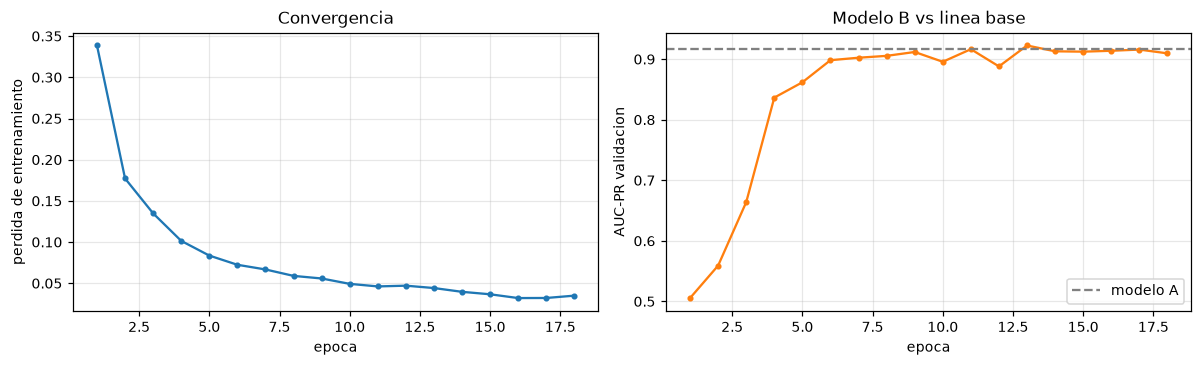

In [33]:
fig, ejes = plt.subplots(1, 2, figsize=(11, 3.4))
ejes[0].plot(historial_b.epoca, historial_b.perdida_train, marker="o", ms=3)
ejes[0].set(xlabel="epoca", ylabel="perdida de entrenamiento", title="Convergencia")
ejes[1].plot(historial_b.epoca, historial_b.auc_pr_val, marker="o", ms=3, color="tab:orange")
ejes[1].axhline(auc_pr(y_val, s_a_val), ls="--", c="gray", label="modelo A")
ejes[1].set(xlabel="epoca", ylabel="AUC-PR validacion", title="Modelo B vs linea base")
ejes[1].legend()
plt.tight_layout()
plt.savefig(DIR_FIGURAS / "entrenamiento_b.png", dpi=130, bbox_inches="tight")
plt.show()

In [34]:
ruta_b = DIR_ARTEFACTOS / "modelo_b.pt"
torch.save({"pesos": red_b.state_dict(), "arquitectura": cfg_b["arquitectura"],
            "oculto": cfg_b["oculto"], "n_num": int(num_z.shape[1]),
            "umbral_val": umbral_b}, ruta_b)
print(f"artefacto: {ruta_b.name} ({ruta_b.stat().st_size/1e3:.0f} KB)")
print("para recargarlo: correr las celdas de definicion de este bloque y hacer load_state_dict")

artefacto: modelo_b.pt (224 KB)
para recargarlo: correr las celdas de definicion de este bloque y hacer load_state_dict


### 2.3 Comparación común A vs B

Lo que se mantiene idéntico entre los dos modelos, para que la diferencia sea atribuible al
modelo y no al montaje: los **mismos datos** (una sola corrida del generador), la **misma
partición** temporal, el **mismo horizonte** (¿es fraude la transacción que ocurre ahora?), el
**mismo tratamiento del desbalance** y la **misma regla de umbral** (el que minimiza costo
esperado sobre validación).

Lo único que cambia es la representación: A ve 20 agregadas de ventana, B ve los 20 eventos en
orden.

Todo lo que sigue está calculado sobre **validación**. El conjunto de prueba no se toca hasta el
bloque 5, después de fijar el umbral.

In [35]:
puntajes_val = {"A (agregadas)": s_a_val, "B (secuencial)": s_b_val}
umbrales_val = {"A (agregadas)": umbral_a, "B (secuencial)": umbral_b}
resumen_modelos(y_val, puntajes_val, umbrales_val).round(4)

,auc_pr,umbral,precision,exhaustividad,f1,alertas,vp,fp,fn,costo_Q
modelo,,,,,,,,,,
A (agregadas),0.9171,0.1217,0.5670,0.9879,0.7204,1150,652,498,8,123240
B (secuencial),0.9226,0.3776,0.5863,0.9833,0.7346,1107,649,458,11,128640


**Dos lecturas que apuntan en direcciones distintas.** B tiene mejor AUC-PR (0.9226 contra 0.9171)
pero **cuesta más** en su punto de operación: Q128,640 contra Q123,240.

No es una contradicción. El AUC-PR resume el desempeño en *todos* los umbrales; el costo depende de
**uno solo**. En su umbral óptimo B cambia 40 falsos positivos menos por 3 falsos negativos más, y
con Q4,200 contra Q180 ese canje sale mal: ahorra 40 × 180 = Q7,200 y paga 3 × 4,200 = Q12,600.
La diferencia de Q5,400 es exactamente la que se observa.

La lección para el comité es que **ordenar modelos por AUC-PR no equivale a ordenarlos por dinero**,
y que la decisión del bloque 5 debe tomarse sobre la curva de costo, no sobre esta tabla.

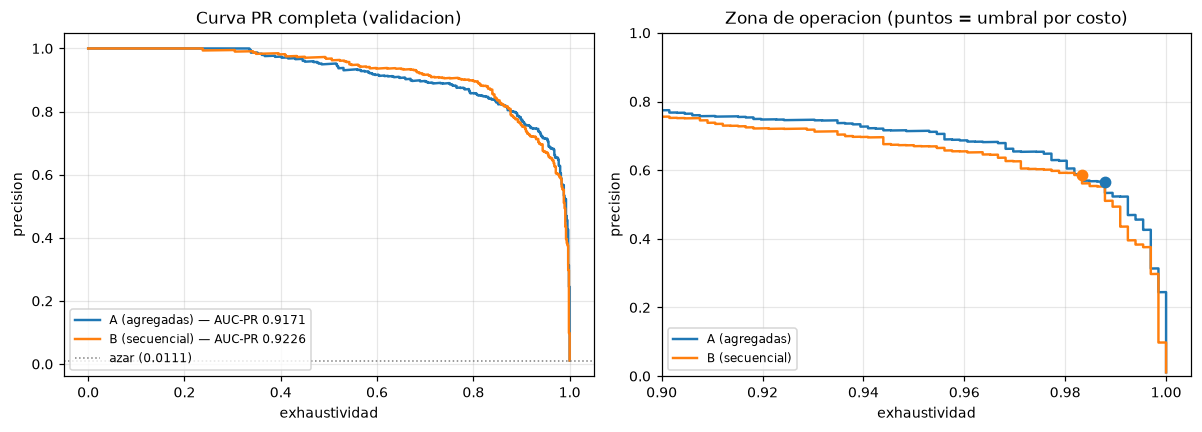

In [36]:
fig, ejes = plt.subplots(1, 2, figsize=(11, 4))
for nombre, s in puntajes_val.items():
    p, r, _ = precision_recall_curve(y_val, s)
    ejes[0].plot(r, p, lw=1.6, label=f"{nombre} — AUC-PR {auc_pr(y_val, s):.4f}")
ejes[0].axhline(y_val.mean(), ls=":", c="gray", lw=1, label=f"azar ({y_val.mean():.4f})")
ejes[0].set(xlabel="exhaustividad", ylabel="precision", title="Curva PR completa (validacion)")
ejes[0].legend(loc="lower left", fontsize=8)

for nombre, s in puntajes_val.items():
    p, r, _ = precision_recall_curve(y_val, s)
    ejes[1].plot(r, p, lw=1.6, label=nombre)
for nombre, s in puntajes_val.items():
    m = metricas(y_val, s, umbrales_val[nombre])
    ejes[1].scatter([m["exhaustividad"]], [m["precision"]], s=45, zorder=5)
ejes[1].set(xlim=(0.90, 1.005), ylim=(0.0, 1.0), xlabel="exhaustividad", ylabel="precision",
            title="Zona de operacion (puntos = umbral por costo)")
ejes[1].legend(loc="lower left", fontsize=8)
plt.tight_layout()
plt.savefig(DIR_FIGURAS / "pr_A_vs_B.png", dpi=130, bbox_inches="tight")
plt.show()

**¿La diferencia de 0.0055 es real o es ruido?** Con 660 fraudes en validación, una diferencia tan
pequeña merece un intervalo antes que un titular. Se remuestrean **tarjetas**, no filas: las
secuencias de una misma tarjeta están correlacionadas y tratarlas como independientes estrecharía
artificialmente el intervalo.

In [37]:
tarjeta_val = tx.id_tarjeta.to_numpy()[datos.fila_tx[idx["val"]]]


def bootstrap_diferencia(y, s_base, s_alt, grupo, n=400, seed=SEED):
    """Distribucion de (AUC-PR alt - AUC-PR base) remuestreando tarjetas con reemplazo."""
    rng = np.random.default_rng(seed)
    unicas, inverso = np.unique(grupo, return_inverse=True)
    posiciones = [np.flatnonzero(inverso == k) for k in range(unicas.size)]
    difs, hechas = np.empty(n), 0
    while hechas < n:
        muestra = np.concatenate([posiciones[k] for k in rng.integers(0, unicas.size, unicas.size)])
        if y[muestra].sum() == 0:
            continue
        difs[hechas] = auc_pr(y[muestra], s_alt[muestra]) - auc_pr(y[muestra], s_base[muestra])
        hechas += 1
    return difs


difs_ba = bootstrap_diferencia(y_val, s_a_val, s_b_val, tarjeta_val)
lo, hi = np.percentile(difs_ba, [2.5, 97.5])

print(f"diferencia observada B - A : {auc_pr(y_val, s_b_val) - auc_pr(y_val, s_a_val):+.4f}")
print(f"IC 95 % (bootstrap x400)   : [{lo:+.4f}, {hi:+.4f}]")
print(f"P(B > A)                   : {(difs_ba > 0).mean():.3f}")

diferencia observada B - A : +0.0055
IC 95 % (bootstrap x400)   : [-0.0148, +0.0254]
P(B > A)                   : 0.688


**El intervalo incluye el cero.** Con esta evidencia **no se puede afirmar que B sea mejor que A a
nivel global**: la ventaja de 0.0055 es compatible con el ruido de muestreo, y en 31 de cada 100
remuestreos A queda por encima.

Este es el resultado honesto y hay que decirlo tal cual, no maquillarlo. Si el informe se detuviera
aquí, la recomendación al comité sería **no** incorporar un modelo de secuencias: cuesta más
entrenar, cuesta más operar y no rinde una mejora demostrable.

Pero un promedio sobre tres mecanismos distintos puede esconder lo que pasa en cada uno. La
predicción escrita en 1.4 —antes de entrenar nada— era que B ganaría **solo** en F1. Esa predicción
se pone a prueba en el bloque 3, y es ahí donde se decide la pregunta del comité.

**Vista operativa.** El área de riesgos no opera con un umbral abstracto sino con una capacidad de
revisión finita. A presupuesto de alertas fijo, los dos modelos son prácticamente el mismo:

In [38]:
filas_presupuesto = []
for presupuesto in (400, 600, 800, 1000, 1200):
    fila = {"alertas": presupuesto}
    for nombre, s in puntajes_val.items():
        m = metricas(y_val, s, np.sort(s)[-presupuesto])
        fila[f"{nombre[0]} exhaustividad"] = round(m["exhaustividad"], 4)
        fila[f"{nombre[0]} precision"] = round(m["precision"], 4)
    filas_presupuesto.append(fila)
pd.DataFrame(filas_presupuesto)

,alertas,A exhaustividad,A precision,B exhaustividad,B precision
0,400,0.5652,0.9325,0.5712,0.9425
1,600,0.7909,0.8700,0.8106,0.8917
2,800,0.9152,0.7550,0.9076,0.7488
3,1000,0.9773,0.6450,0.9667,0.6380
4,1200,0.9879,0.5433,0.9879,0.5433


B es algo mejor cuando la capacidad es baja (400–600 alertas) y A lo alcanza o lo supera cuando es
alta. Ninguna de las dos ventajas supera el margen de incertidumbre que acaba de medirse.

## Bloque 3 — ¿De verdad usó el orden?

> **Evidencia 3 del informe: valor del orden.**
> Una mejora de métricas no demuestra por sí sola que el modelo leyó la secuencia. Estas dos
> pruebas intentan refutar nuestra propia conclusión.

### 3.1 Prueba obligatoria — permutación controlada  *(T8)*

In [39]:
# TODO (T8): barajar el orden DENTRO de cada secuencia, sin tocar eventos ni agregadas

### 3.2 Segunda prueba — desempeño por mecanismo de fraude  *(T9)*

In [40]:
# TODO (T9): AUC-PR de A y B desglosado por F1 / F2 / F3

## Bloque 4 — Apuesta del equipo

> **Evidencia 4 del informe: apuesta del equipo.**
> Hipótesis previa, control experimental, métrica de éxito y veredicto — aunque falle.

**La hipótesis se escribe ANTES de entrenar C y ANTES de tocar el conjunto de prueba.**

### 4.1 Hipótesis previa  *(T10)*

> Creemos que ______ mejorará ______ porque ______. Lo consideraremos útil si ______.

_(pendiente — T10)_

In [41]:
# TODO (T11): entrenar C y su control, y emitir veredicto explicito

## Bloque 5 — Umbral, costo y recomendación

> **Evidencias 5 y 6 del informe: decisión económica, recomendación y límites.**
> Un fraude no detectado cuesta Q4,200; bloquear una transacción legítima cuesta Q180. El umbral se
> elige barriendo **validación** y se aplica una sola vez a prueba.

In [42]:
# TODO (T12): barrido de umbral por costo esperado y proyeccion mensual

## Matriz de evidencias

| Evidencia | Figura o tabla | Conclusión | Limitación |
|---|---|---|---|
| 1 — Integridad de datos | _(pendiente)_ | | |
| 2 — Comparación común A vs B | _(pendiente)_ | | |
| 3 — Valor del orden | _(pendiente)_ | | |
| 4 — Apuesta del equipo | _(pendiente)_ | | |
| 5 — Decisión económica | _(pendiente)_ | | |
| 6 — Recomendación y límites | _(pendiente)_ | | |